### EDA EXPERIMENTATION

- Data used : *`iris`* of ***Seaborn***
- _ 
___

#### 1rst STEP : IMPORTATION DES BIBLIOTHÈQUES
```sh
pip install <packages_name>
```

In [4]:
# import machine_learning as ml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
%matplotlib inline

#### 2nd STEP : IMPORTATION DES DONNÉES

In [5]:
iris_df = sns.load_dataset('iris')

In [6]:
iris_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


---

#### 3rd STEP : INFORMATIONS SUR LES DONNÉES DU DATASET

In [7]:
# print(f"Dataset shape: {iris_df.shape} (rows, columns)")

```py
"""
>>> INFORMATIONS STATISTIQUES ET DÉTAILLÉES DES DONNÉES DU DATASETS [les ÉTIQUETTES]
"""
```

In [8]:
iris_df.info()  # detailed informations on dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


```py
"""
>>> STATISTIQUE DESCRIPTIVE SUR LES DONNÉES NUMÉRIQUES
"""
```

In [9]:
iris_df.describe().round(2)   # data descrirtions

,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


___

#### 4th STEP : DÉTECTION DES VALEURS POUVANT AFFECTER LA QUALITÉ DE L'ANALYSE ET PAR SUITE DU MODÈLE

##### Catégorie A : Valeurs Manquantes
```
>>>
```

In [10]:
print(f"Missing values:\n{'='*72}")
iris_df.isna().head()

Missing values:


,sepal_length,sepal_width,petal_length,petal_width,species
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False


In [11]:
print(f"\t Missing values count:\n{'='*72}\n{iris_df.isna().sum()}")

	 Missing values count:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


##### Catégorie B : Valeurs Dupliqées
```
>>>
```

In [12]:
print(iris_df.duplicated())
f"Count Of duplicated values: {int(f"{iris_df.duplicated().sum()}")}"

0      False
1      False
2      False
3      False
4      False
       ...  
145    False
146    False
147    False
148    False
149    False
Length: 150, dtype: bool


'Count Of duplicated values: 1'

In [14]:
iris_df[iris_df.duplicated()].sort_values(by=list(iris_df.columns))

,sepal_length,sepal_width,petal_length,petal_width,species
142,5.8,2.7,5.1,1.9,virginica


In [20]:
iris_ = iris_df.copy()   # copying

In [21]:
iris_df = iris_df.drop_duplicates()

In [22]:
iris_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


##### Catégorie C : Valeurs Aberrantes
```py
"""
>>> IQR methods
"""
```

___

### >>> Missing_(None) & Duplicated_(1) values

In [28]:
iris_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [83]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

<Axes: >

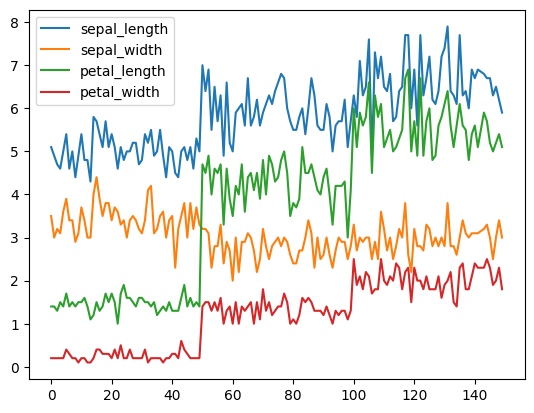

In [40]:
iris_df.plot()

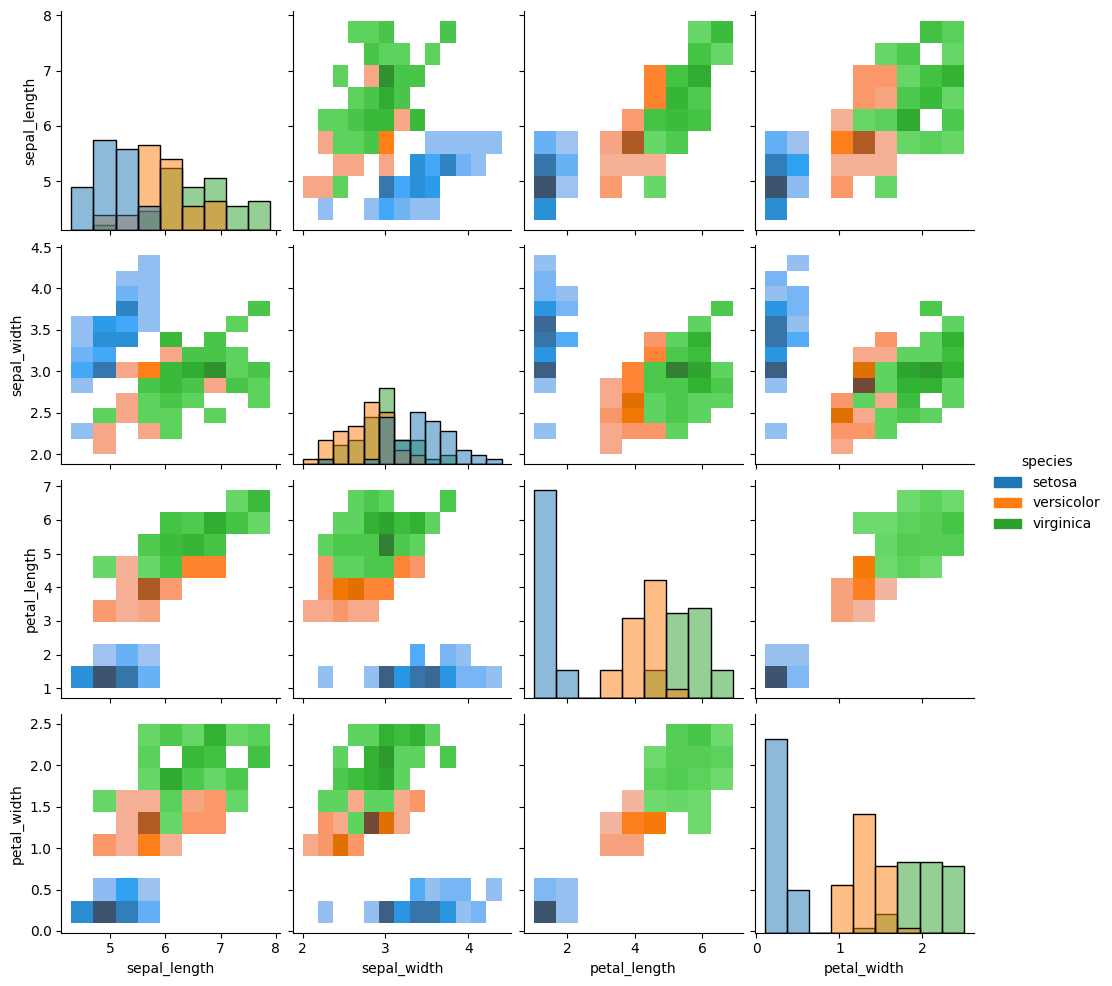

In [44]:
sns.pairplot(iris_df, hue="species", kind="hist")

---

In [80]:
encoder = LabelEncoder()

In [81]:
# Encoding Values
iris_encd = encoder.fit_transform(iris_df['species'])
iris_encd

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [45]:
X = iris_df.drop("species", axis=1)
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [46]:
y = iris_df["species"]
y

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 149, dtype: object

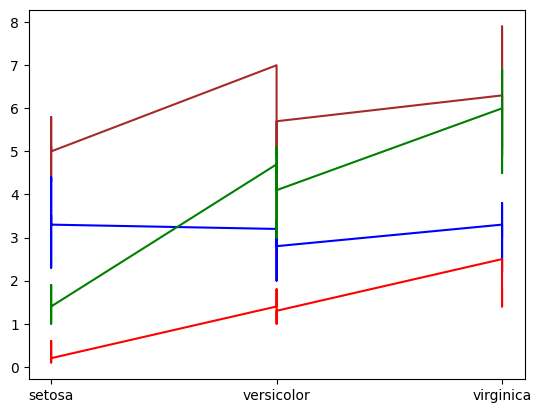

In [82]:
color = ['brown', 'blue', 'green', 'red']
fig, ax = plt.subplots()
for axIndex, x in enumerate(X):
    # plt.subplots(4,4)
    ax.plot(y, X[x], color[axIndex])

In [ ]:
stdScaler = StandardScaler()
X_train = stdScaler.fit_transform(X_train)
X_test = stdScaler.transform(X_test)

---

In [ ]:
# Splitting Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [ ]:
# Creating Model


In [ ]:
# Training Model

___